In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/sample_data/ecommerce_customer_data_custom_ratios.csv")

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12.0,3.0,740.0,Credit Card,37.0,0.0,Christine Hernandez,37.0,Male,0.0
1,46251,2022-03-05 12:56:35,Home,468.0,4.0,2739.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
2,46251,2022-05-23 18:18:01,Home,288.0,2.0,3196.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
3,46251,2020-11-12 13:13:29,Clothing,196.0,1.0,3509.0,PayPal,37.0,0.0,Christine Hernandez,37.0,Male,0.0
4,13593,2020-11-27 17:55:11,Home,449.0,1.0,3452.0,Credit Card,49.0,0.0,James Grant,49.0,Female,1.0


In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,1
Quantity,1
Total Purchase Amount,1
Payment Method,1
Customer Age,1
Returns,4616
Customer Name,1


In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,24479.000000,24478.000000,24478.000000,24478.000000,24478.000000,19863.000000,24478.000000,24478.000000
mean,24822.010335,253.792017,3.005352,2718.708269,43.530762,0.503499,43.530762,0.202386
std,14387.284186,141.746343,1.414073,1449.870450,15.311440,0.500000,15.311440,0.401787
min,14.000000,10.000000,1.000000,108.000000,18.000000,0.000000,18.000000,0.000000
25%,12286.000000,130.000000,2.000000,1459.000000,30.000000,0.000000,30.000000,0.000000
50%,25171.000000,255.000000,3.000000,2719.000000,43.000000,1.000000,43.000000,0.000000
75%,37019.000000,377.000000,4.000000,3984.000000,56.000000,1.000000,56.000000,0.000000
max,49988.000000,500.000000,5.000000,5345.000000,70.000000,1.000000,70.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24479 entries, 0 to 24478
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            24479 non-null  int64  
 1   Purchase Date          24479 non-null  object 
 2   Product Category       24479 non-null  object 
 3   Product Price          24478 non-null  float64
 4   Quantity               24478 non-null  float64
 5   Total Purchase Amount  24478 non-null  float64
 6   Payment Method         24478 non-null  object 
 7   Customer Age           24478 non-null  float64
 8   Returns                19863 non-null  float64
 9   Customer Name          24478 non-null  object 
 10  Age                    24478 non-null  float64
 11  Gender                 24478 non-null  object 
 12  Churn                  24478 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 2.4+ MB


In [ ]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,float64
Quantity,float64
Total Purchase Amount,float64
Payment Method,object
Customer Age,float64
Returns,float64
Customer Name,object


In [ ]:
name_of_col_having_more_zeores = [features for features in df.columns if df[features].isnull().sum()>=4]

In [ ]:
name_of_col_having_more_zeores

['Returns']

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,1
Quantity,1
Total Purchase Amount,1
Payment Method,1
Customer Age,1
Returns,4616
Customer Name,1


In [ ]:
count = df['Product Category'].value_counts()

In [ ]:
labels = df['Product Category'].value_counts().index
counts = df['Product Category'].value_counts().values

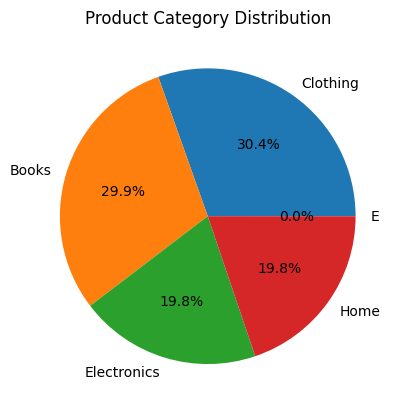

In [ ]:
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title("Product Category Distribution")
plt.show()

In [ ]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')
df['Purchase Date'].dt.year

,Purchase Date
0,2020
1,2022
2,2022
3,2020
4,2020
...,...
24474,2023
24475,2023
24476,2023
24477,2021


In [ ]:
df['selling_price'] = df['Quantity'] * df['Product Price']

In [ ]:
df['selling_price']

,selling_price
0,36.0
1,1872.0
2,576.0
3,196.0
4,449.0
...,...
24474,259.0
24475,450.0
24476,1140.0
24477,105.0


In [ ]:
import pandas as pd

# 1️⃣ Convert Purchase Date to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')

# 2️⃣ Create Year column from Purchase Date
df['Year'] = df['Purchase Date'].dt.year

# 3️⃣ Create Selling Price column
df['Selling Price'] = df['Quantity'] * df['Product Price']

# 4️⃣ Calculate Yearly Total Sales
yearly_sales = df.groupby('Year')['Selling Price'].sum()

print(yearly_sales)

Year
2020    5097458.0
2021    4985488.0
2022    4885229.0
2023    3675738.0
Name: Selling Price, dtype: float64


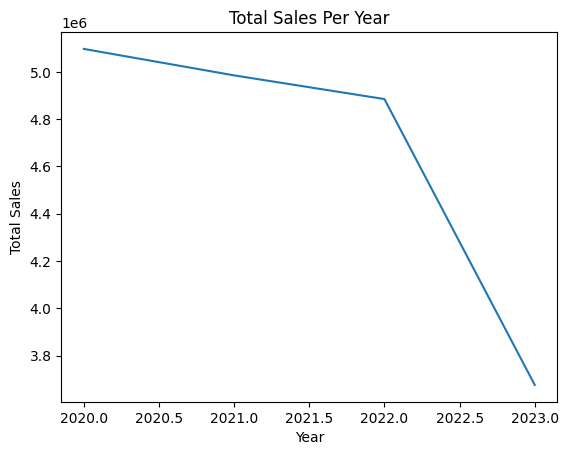

In [ ]:
plt.figure()
plt.plot(yearly_sales.index, yearly_sales.values)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales Per Year")

plt.show()

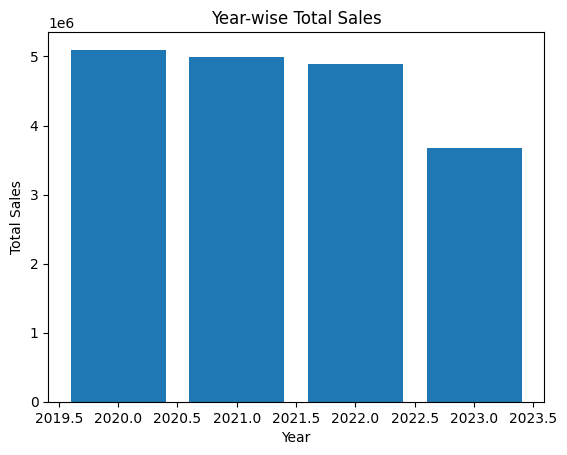

In [ ]:
plt.figure()
plt.bar(yearly_sales.index, yearly_sales.values)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Year-wise Total Sales")

plt.show()

In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn', 'Year',
       'selling_price', 'Selling Price'],
      dtype='object')

In [ ]:
df['Total Purchase Amount'].sum()

np.float64(66548541.0)

In [ ]:
df['Selling Price'].sum()

np.float64(18643913.0)

In [ ]:
count = df['Payment Method'].value_counts()

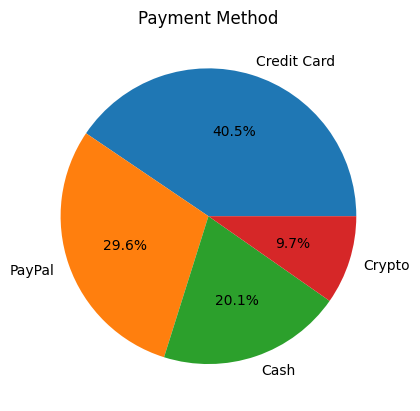

In [ ]:
plt.pie(count, labels=count.index, autopct='%1.1f%%')
plt.title("Payment Method")
plt.show()